In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
PATH_COBESST = '/glade/campaign/cgd/oce/people/rita/COBESST2/'
PATH_ERA = '/glade/campaign/cgd/oce/people/rita/ERA5/'

filename_COBESST = 'COBESST_189101_201912_Rita_20241205.nc'
filename_ERA = 'ERA5_sst_ice_1940_2023_yearly.nc'

mask_COBESST_raw = xr.open_dataset('/glade/campaign/cgd/oce/people/rita/COBESST/sst.mon.mean.nc')
mask_ERA_raw = xr.open_dataset(PATH_ERA + '1940/194001_hres_cisst.nc')
                           # mask = xr.where(np.isnan(sst.isel(time=0)), 0, 1)  # Use first time step


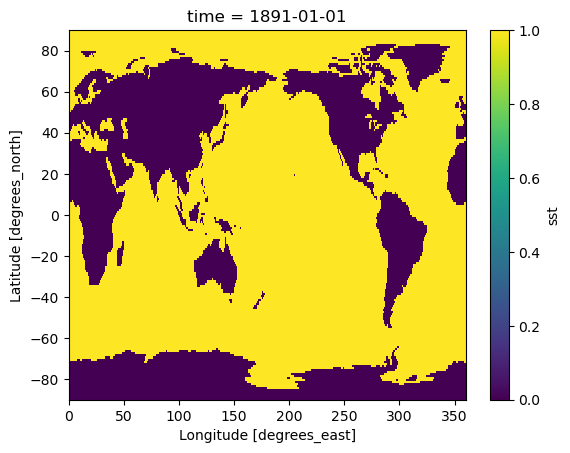

In [25]:
mask_COBESST = xr.where(np.isnan(mask_COBESST_raw.sst.isel(time=0)), 0, 1)
mask_COBESST.plot()

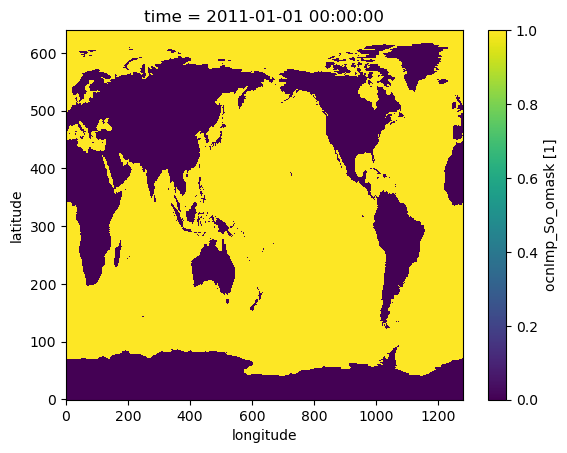

In [33]:
PATH3_grid = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.2001_2010_test/cpl/hist/'
filename3_grid = 'a.e30.A_ERA5.TL319_t232.2001_2010_test.cpl.hi.2011-01-01-00000.nc'
area3_raw = xr.open_dataset(PATH3_grid + filename3_grid, engine="netcdf4")['MED_ocn_area'].isel(time=0)
mask_era = xr.open_dataset(PATH3_grid + filename3_grid, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "latitude", "ocnImp_nx": "longitude"})

mask_era.plot()

In [32]:
ds_cobe = xr.open_dataset(PATH_COBESST + filename_COBESST)
ds_era = xr.open_dataset(PATH_ERA + filename_ERA)

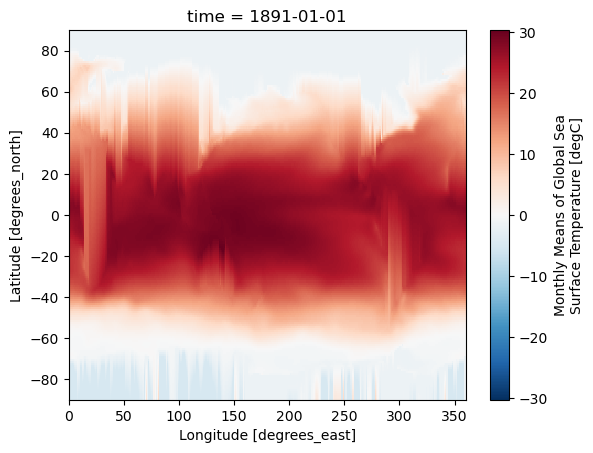

In [11]:
ds_cobe.SST_cpl.isel(time=0).plot()

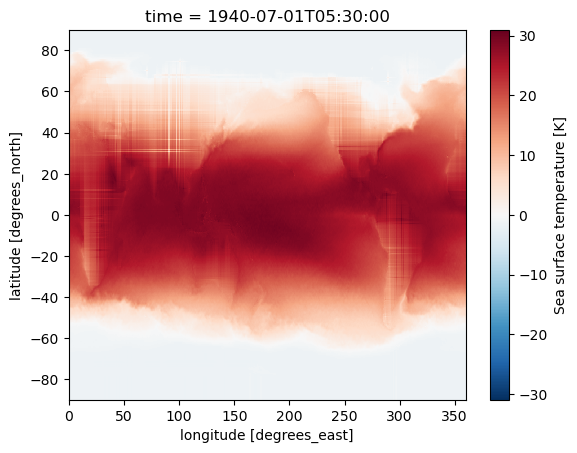

In [13]:
ds_era.SST_cpl.isel(time = 0).plot()

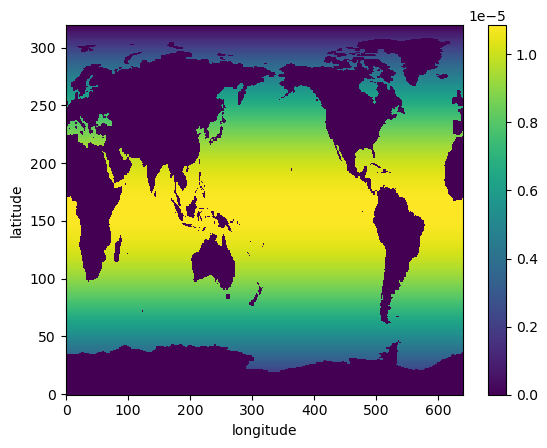

In [88]:
PATH2_grid= '/glade/campaign/cgd/oce/people/rita/JRA55raw/landsea_mask/'
filename2_grid = 'JRA55_grid_file.nc'
area_jra = xr.open_dataset(PATH2_grid + filename2_grid, engine="netcdf4")['tarea'].rename({"i": "longitude", "j": "latitude"})
mask_jra = 1 - xr.open_dataset(PATH2_grid + filename2_grid, engine="netcdf4")['tmask'].rename({"i": "longitude", "j": "latitude"})

weights_jra = ((mask_jra * area_jra)/np.sum(area_jra*mask_jra))
weights_jra = weights_jra.fillna(0)#.rename({"i": "longitude", "j": "latitude"})

weights_jra.plot()

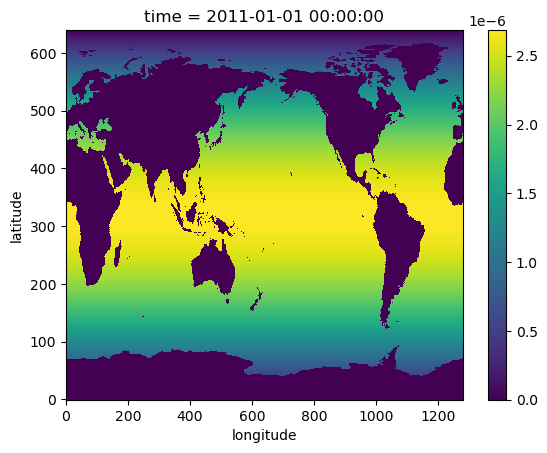

In [87]:
PATH3_grid = '/glade/derecho/scratch/mmarkina/archive/a.e30.A_ERA5.TL319_t232.2001_2010_test/cpl/hist/'
filename3_grid = 'a.e30.A_ERA5.TL319_t232.2001_2010_test.cpl.hi.2011-01-01-00000.nc'
area3_raw = xr.open_dataset(PATH3_grid + filename3_grid, engine="netcdf4")['MED_ocn_area'].isel(time=0)
mask_era = xr.open_dataset(PATH3_grid + filename3_grid, engine="netcdf4")['ocnImp_So_omask'].isel(time=0).rename({"ocnImp_ny": "latitude", "ocnImp_nx": "longitude"})

R2 = 6371e3**2
area_era = (area3_raw*R2).rename({"MED_ocn_ny": "latitude", "MED_ocn_nx": "longitude"})

weights_era = ((mask_era * area_era)/np.sum(area_era*mask_era))
weights_era = weights_era.fillna(0)#.rename({"x": "longitude", "y": "latitude"})

weights_era.plot()

In [85]:
mask_era

<xarray.DataArray 'ocnImp_So_omask' (y: 640, x: 1280)> Size: 7MB
[819200 values with dtype=float64]
Coordinates:
    time     object 8B 2011-01-01 00:00:00
Dimensions without coordinates: y, x
Attributes:
    units:          1
    standard_name:  ocnImp_So_omask

In [29]:
def compute_weighted_mean(array_name, weights):
    var_time_series = array_name.weighted(weights).mean(dim=["latitude", "longitude"])
    var_time_series["time"] = pd.to_datetime([t.strftime('%Y-%m-%d') for t in var_time_series["time"].values])
    # yearly_mean = var_time_series.resample(time="1YE").mean()
    return var_time_series

In [79]:
swdn_means1 = swdn1.swdn.weighted(weights_jra).mean(dim=["latitude", "longitude"])
swdn_means1['time'] = pd.date_range(start="1958-01-01", end="2023-01-01", freq="YS")
swdn_means2 = swdn2.swdn.weighted(weights_jra).mean(dim=["latitude", "longitude"])
swdn_means2['time'] = pd.date_range(start="1958-01-01", end="2020-01-01", freq="YS")
swdn_means3 = swdn3.swdn.weighted(weights_era).mean(dim=["latitude", "longitude"])
swdn_means3['time'] = pd.date_range(start="1940-01-01", end="2020-01-01", freq="YS")

In [46]:
lwdn_means1 = lwdn1.lwdn.weighted(weights_jra).mean(dim=["latitude", "longitude"])
lwdn_means1['time'] = pd.date_range(start="1958-01-01", end="2023-01-01", freq="YS")
lwdn_means2 = lwdn2.lwdn.weighted(weights_jra).mean(dim=["latitude", "longitude"])
lwdn_means2['time'] = pd.date_range(start="1958-01-01", end="2020-01-01", freq="YS")
lwdn_means3 = lwdn3.lwdn.weighted(weights_era).mean(dim=["latitude", "longitude"])
lwdn_means3['time'] = pd.date_range(start="1940-01-01", end="2020-01-01", freq="YS")

In [62]:
temp_means1 = temp1.t_10.weighted(weights_jra).mean(dim=["latitude", "longitude"])
temp_means1['time'] = pd.date_range(start="1958-01-01", end="2019-01-01", freq="YS")
temp_means2 = temp2.t_10.weighted(weights_jra).mean(dim=["latitude", "longitude"])
temp_means2['time'] = pd.date_range(start="1958-01-01", end="2020-01-01", freq="YS")
temp_means3 = temp3.t_10.weighted(weights_era).mean(dim=["latitude", "longitude"])
temp_means3['time'] = pd.date_range(start="1940-01-01", end="2020-01-01", freq="YS")

In [91]:
prec_means1 = (prec1.prec).weighted(weights_jra).mean(dim=["latitude", "longitude"])
prec_means1['time'] = pd.date_range(start="1958-01-01", end="2020-01-01", freq="YS")
prec_means2 = (prec2.prec).weighted(weights_jra).mean(dim=["latitude", "longitude"])
prec_means2['time'] = pd.date_range(start="1958-01-01", end="2020-01-01", freq="YS")
prec_means3 = (prec3.prec).weighted(weights_era).mean(dim=["latitude", "longitude"])
prec_means3['time'] = pd.date_range(start="1940-01-01", end="2020-01-01", freq="YS")

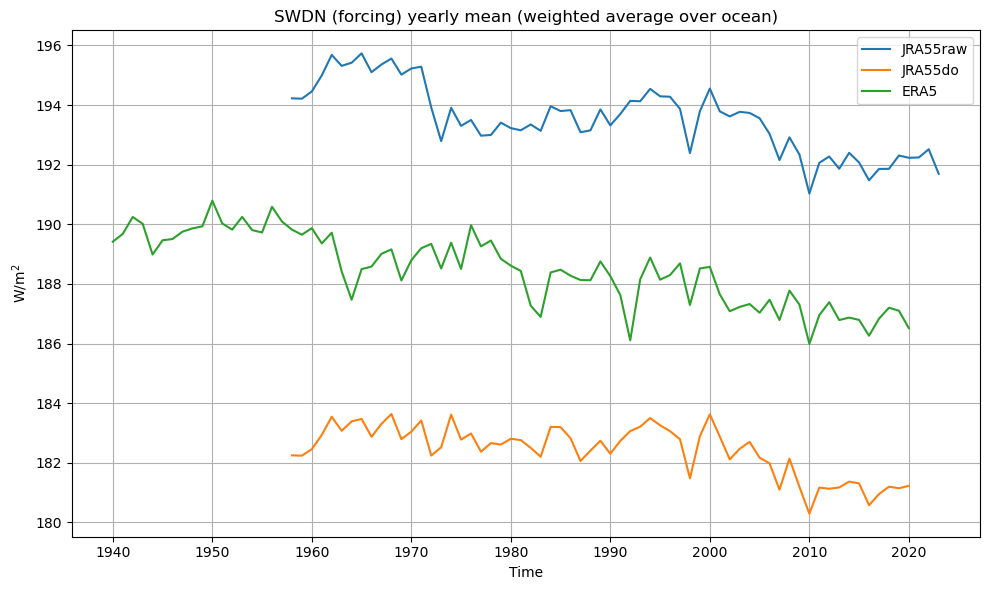

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(swdn_means1["time"], swdn_means1, label=f"JRA55raw")
plt.plot(swdn_means2["time"], swdn_means2, label=f"JRA55do")
plt.plot(swdn_means3["time"], swdn_means3, label=f"ERA5")
plt.xlabel("Time")
plt.ylabel(r"$\mathrm{W/m^2}$")
plt.title(f"SWDN (forcing) yearly mean (weighted average over ocean)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

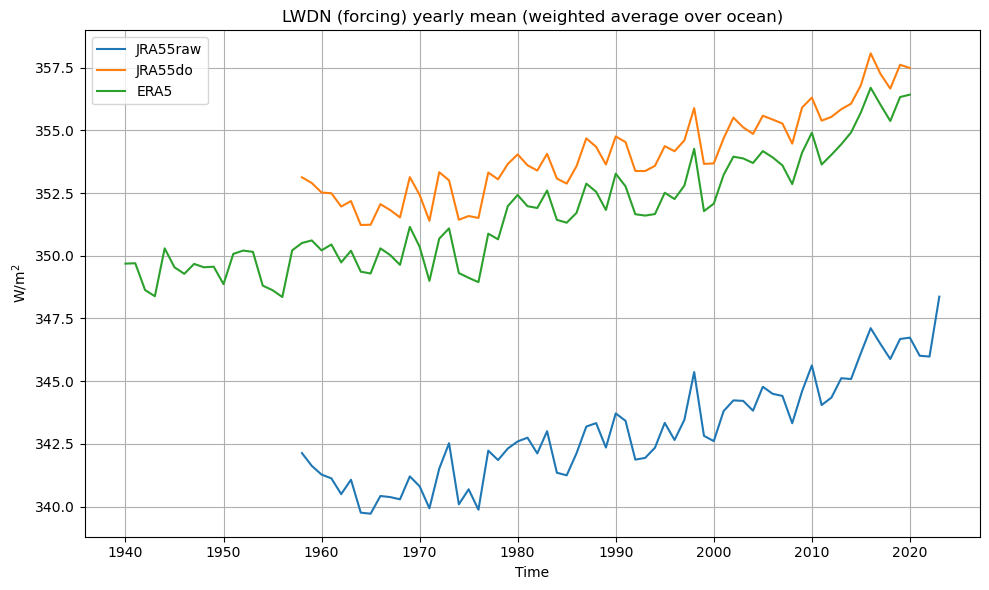

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(lwdn_means1["time"], lwdn_means1, label=f"JRA55raw")
plt.plot(lwdn_means2["time"], lwdn_means2, label=f"JRA55do")
plt.plot(lwdn_means3["time"], lwdn_means3, label=f"ERA5")
plt.xlabel("Time")
plt.ylabel(r"$\mathrm{W/m^2}$")
plt.title(f"LWDN (forcing) yearly mean (weighted average over ocean)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

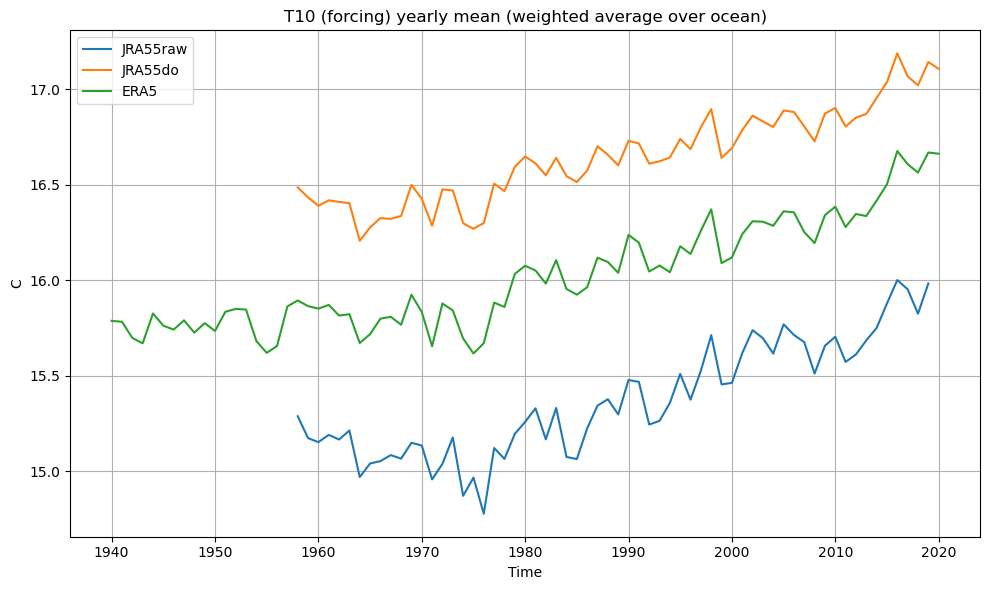

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(temp_means1["time"], temp_means1-273.15, label=f"JRA55raw")
plt.plot(temp_means2["time"], temp_means2-273.15, label=f"JRA55do")
plt.plot(temp_means3["time"], temp_means3-273.15, label=f"ERA5")
plt.xlabel("Time")
plt.ylabel("C")
plt.title(f"T10 (forcing) yearly mean (weighted average over ocean)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

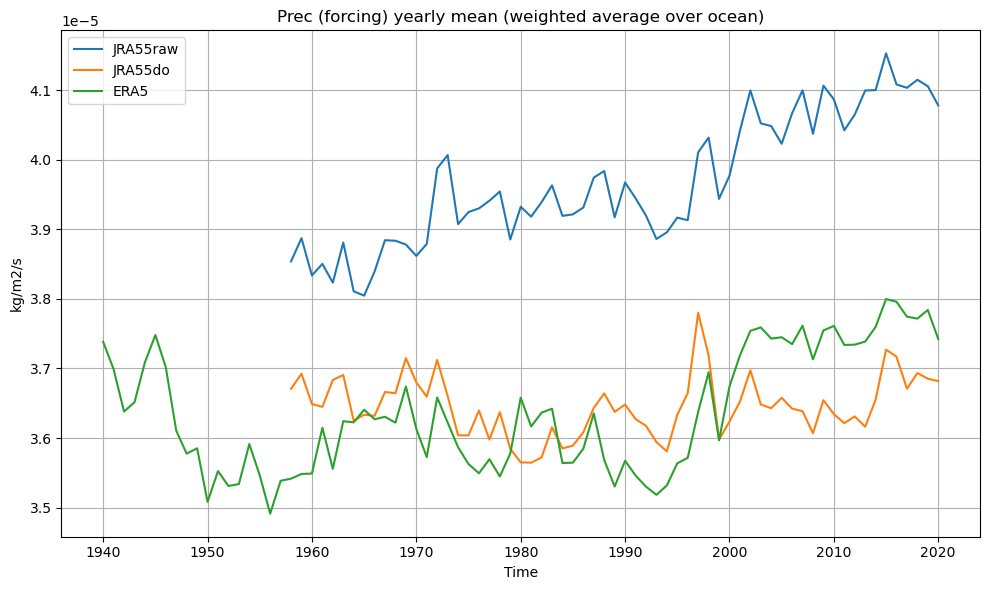

In [92]:
plt.figure(figsize=(10, 6))
plt.plot(prec_means1["time"], prec_means1, label=f"JRA55raw")
plt.plot(prec_means2["time"], prec_means2, label=f"JRA55do")
plt.plot(prec_means3["time"], prec_means3, label=f"ERA5")
plt.xlabel("Time")
plt.ylabel("kg/m2/s")
plt.title(f"Prec (forcing) yearly mean (weighted average over ocean)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()